**Importing Essential Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


**Accessing Google Drive to Access Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Loading Dataset**

In [ ]:
# Dataset Path in Drive
BDD100K_ROOT =  '/content/drive/MyDrive/bdd100k/bdd100k'

# Image paths
Train_Image_Path = os.path.join(BDD100K_ROOT, 'images', 'train')
Val_Image_Path = os.path.join(BDD100K_ROOT, 'images', 'val')
Test_Image_Path = os.path.join(BDD100K_ROOT, 'images', 'test')

# Mask paths (PNG labels)
Train_Mask_Path = os.path.join(BDD100K_ROOT, 'color_labels', 'train')
Val_Mask_Path = os.path.join(BDD100K_ROOT, 'color_labels', 'val')

#Checking whether data is exists in the path
print("=" * 60)
print("BDD100K Segmentation Dataset Paths")
print("=" * 60)
print(f"Train Images: {Train_Image_Path} - Exists: {os.path.exists(Train_Image_Path)}")
print(f"Train Masks: {Train_Mask_Path} - Exists: {os.path.exists(Train_Mask_Path)}")
print(f"Val Images: {Val_Image_Path} - Exists: {os.path.exists(Val_Image_Path)}")
print(f"Val Masks: {Val_Mask_Path} - Exists: {os.path.exists(Val_Mask_Path)}")

BDD100K Segmentation Dataset Paths
Train Images: /content/drive/MyDrive/bdd100k/bdd100k/images/train - Exists: True
Train Masks: /content/drive/MyDrive/bdd100k/bdd100k/color_labels/train - Exists: True
Val Images: /content/drive/MyDrive/bdd100k/bdd100k/images/val - Exists: True
Val Masks: /content/drive/MyDrive/bdd100k/bdd100k/color_labels/val - Exists: True


**Defining classes and Colors for Each Class**

In [ ]:
# List of classes for semantic segmentation
BDD_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
    'traffic light', 'traffic sign', 'vegetation', 'terrain', 'sky',
    'person', 'rider', 'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle'
]

# These are standard colors codes for each classes (RGB Codes)
BDD_COLORS = [
    (128, 64, 128),   # road
    (244, 35, 232),    # sidewalk
    (70, 70, 70),      # building
    (102, 102, 156),   # wall
    (190, 153, 153),   # fence
    (153, 153, 153),   # pole
    (250, 170, 30),    # traffic light
    (220, 220, 0),     # traffic sign
    (107, 142, 35),    # vegetation
    (152, 251, 152),   # terrain
    (70, 130, 180),    # sky
    (220, 20, 60),     # person
    (255, 0, 0),       # rider
    (0, 0, 142),       # car
    (0, 0, 70),        # truck
    (0, 60, 100),      # bus
    (0, 80, 100),      # train
    (0, 0, 230),       # motorcycle
    (119, 11, 32)      # bicycle
]

print(f"\nNumber of classes: {len(BDD_CLASSES)}\n")
for cls, color in zip(BDD_CLASSES, BDD_COLORS):
    print(f"{cls} : {color}")


Number of classes: 19

road : (128, 64, 128)
sidewalk : (244, 35, 232)
building : (70, 70, 70)
wall : (102, 102, 156)
fence : (190, 153, 153)
pole : (153, 153, 153)
traffic light : (250, 170, 30)
traffic sign : (220, 220, 0)
vegetation : (107, 142, 35)
terrain : (152, 251, 152)
sky : (70, 130, 180)
person : (220, 20, 60)
rider : (255, 0, 0)
car : (0, 0, 142)
truck : (0, 0, 70)
bus : (0, 60, 100)
train : (0, 80, 100)
motorcycle : (0, 0, 230)
bicycle : (119, 11, 32)


**Exploring Dataset**

In [ ]:
def explore_dataset():
    """
    Explore the BDD100K dataset structure and statistics
    """
    print("=" * 60)
    print("DATA EXPLORATION")
    print("=" * 60)

    # 1. Count number of files
    train_images = os.listdir(Train_Image_Path)
    val_images = os.listdir(Val_Image_Path)
    train_masks = os.listdir(Train_Mask_Path)
    val_masks = os.listdir(Val_Mask_Path)

    print(f"Number of training images: {len(train_images)}")
    print(f"Number of training masks: {len(train_masks)}")
    print(f"Number of validation images: {len(val_images)}")
    print(f"Number of validation masks: {len(val_masks)}")

    # 2. Extension of an images
    print("\nFile extensions in training images:")
    extensions = {}
    for img in train_images[:100]:  # Sample first 100
        ext = os.path.splitext(img)[1]
        extensions[ext] = extensions.get(ext, 0) + 1
    print(extensions)

    # 3. Size of an images
    print("\nSample image sizes (Training):")
    for img_name in train_images[:500]:
        img_path = os.path.join(Train_Image_Path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            print(f"{img_name} → {img.shape}")
        else:
            print(f"{img_name} → Unable to read")

     # 4. Extension of an mask images
    print("\nFile extensions in training mask images:")
    extensions = {}
    for img in train_masks[:100]:  # Sample first 100
        ext = os.path.splitext(img)[1]
        extensions[ext] = extensions.get(ext, 0) + 1
    print(extensions)

    # 5. Size of an mask images
    print("\nSample image sizes (Training Masks):")
    for img_name in train_masks[:500]:
        img_path = os.path.join(Train_Mask_Path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            print(f"{img_name} → {img.shape}")
        else:
            print(f"{img_name} → Unable to read")

explore_dataset()

DATA EXPLORATION
Number of training images: 7000
Number of training masks: 7000
Number of validation images: 1000
Number of validation masks: 1000

File extensions in training images:
{'.jpg': 100}

Sample image sizes (Training):
9b0bf112-5edbe682.jpg → (720, 1280, 3)
a110e9ed-9e1e288a.jpg → (720, 1280, 3)
942b6bbc-2425cd08.jpg → (720, 1280, 3)
977b8906-7e0dbdbd.jpg → (720, 1280, 3)
9bd35228-adfe7af8.jpg → (720, 1280, 3)
a1140112-51665c1e.jpg → (720, 1280, 3)
96bbfee1-9cf45d08.jpg → (720, 1280, 3)
9fa7e629-ef470d2b.jpg → (720, 1280, 3)
93f4a763-0e26c204.jpg → (720, 1280, 3)
a00a8844-949dd76f.jpg → (720, 1280, 3)
9c38185c-fc417ba0.jpg → (720, 1280, 3)
9ab509ca-6419a7f9.jpg → (720, 1280, 3)
a1acfdb8-68db64af.jpg → (720, 1280, 3)
97871f2b-7a4f67ca.jpg → (720, 1280, 3)
987b8aba-d3cd2336.jpg → (720, 1280, 3)
94aa8729-28e49e70.jpg → (720, 1280, 3)
97ebca09-17e21801.jpg → (720, 1280, 3)
9c54a254-e72f169b.jpg → (720, 1280, 3)
96d1ea02-2f3303cf.jpg → (720, 1280, 3)
9b24165a-a729ad12.jpg → (720,

**Quick Test to Verify File Existence, Path and Naming**

In [ ]:
def quick_test():
    print("Dataset paths:")
    print(f"Train Image Path: {Train_Image_Path}")
    print(f"Train Mask Path: {Train_Mask_Path}")

    # List a few files
    train_images = os.listdir(Train_Image_Path)[:5]
    print("\nFirst 5 training images:")
    for img in train_images:
        print(f"  - {img}")

    train_masks = os.listdir(Train_Mask_Path)[:5]
    print("\nFirst 5 training masks:")
    for mask in train_masks:
        print(f"  - {mask}")

    # Check one specific pair
    if train_images:
        test_img = train_images[0]
        base_name = os.path.splitext(test_img)[0]
        expected_mask = base_name + '.png'

        print(f"\nTesting first image: {test_img}")
        print(f"Expected mask: {expected_mask}")
        print(f"Mask exists: {expected_mask in train_masks}")

        # Try to load both
        img_path = os.path.join(Train_Image_Path, test_img)
        mask_path = os.path.join(Train_Mask_Path, expected_mask)

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path)

        print(f"Image loaded successfully: {img is not None}")
        print(f"Mask loaded successfully: {mask is not None}")
quick_test()

Dataset paths:
Train Image Path: /content/drive/MyDrive/bdd100k/bdd100k/images/train
Train Mask Path: /content/drive/MyDrive/bdd100k/bdd100k/color_labels/train

First 5 training images:
  - 9b0bf112-5edbe682.jpg
  - a110e9ed-9e1e288a.jpg
  - 942b6bbc-2425cd08.jpg
  - 977b8906-7e0dbdbd.jpg
  - 9bd35228-adfe7af8.jpg

First 5 training masks:
  - 73d972b6-17d447e3_train_color.png
  - 764b5577-907a4edb_train_color.png
  - 7b47f738-08d66ead_train_color.png
  - 8dfd0ed6-2bdf2471_train_color.png
  - 6e44e9a5-83bf7df2_train_color.png

Testing first image: 9b0bf112-5edbe682.jpg
Expected mask: 9b0bf112-5edbe682.png
Mask exists: False
Image loaded successfully: True
Mask loaded successfully: False


**Plotting Class Distribution** - Analyze class distribution in segmentation masks


CLASS DISTRIBUTION ANALYSIS


Analyzing class distribution: 100%|██████████| 50/50 [11:36<00:00, 13.92s/it]


Class Distribution (Top 10):
road: 27.48%
sky: 18.64%
vegetation: 16.92%
building: 16.16%
car: 7.47%
sidewalk: 3.14%
terrain: 2.68%
pole: 2.31%
wall: 1.97%
truck: 1.13%


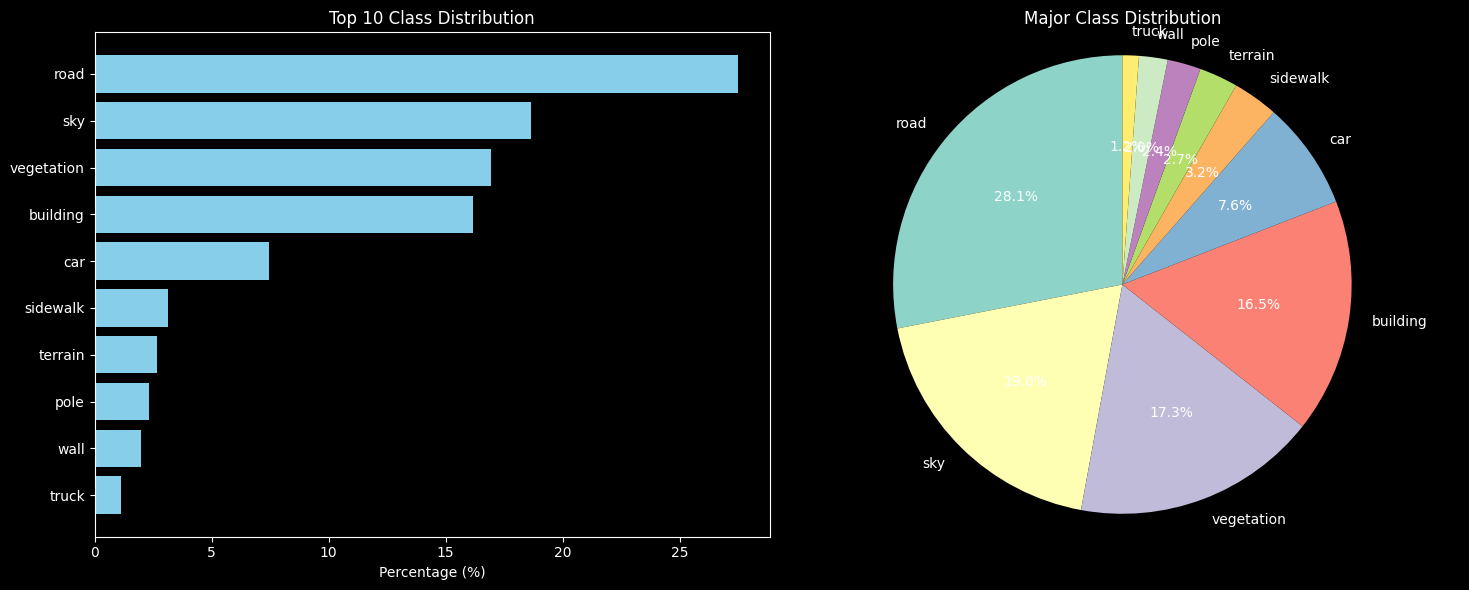

In [ ]:
def analyze_class_distribution():
    print("\n" + "=" * 60)
    print("CLASS DISTRIBUTION ANALYSIS")
    print("=" * 60)

    # Sample masks for analysis
    train_masks = os.listdir(Train_Mask_Path)[:50]
    class_counts = {i: 0 for i in range(len(BDD_CLASSES))}

    for mask_name in tqdm(train_masks, desc="Analyzing class distribution"):
        mask_path = os.path.join(Train_Mask_Path, mask_name)
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask_flat = mask.reshape(-1, 3)
        for pixel in mask_flat:
            for class_id, color in enumerate(BDD_COLORS):
                if np.array_equal(pixel, color):
                    class_counts[class_id] += 1
                    break

    # Calculate percentages
    total_pixels = sum(class_counts.values())
    class_percentages = {k: (v/total_pixels*100 if total_pixels > 0 else 0) for k, v in class_counts.items()}

    # Display results
    print("\nClass Distribution (Top 10):")
    sorted_classes = sorted(class_percentages.items(), key=lambda x: x[1], reverse=True)
    for class_id, percentage in sorted_classes[:10]:
        print(f"{BDD_CLASSES[class_id]}: {percentage:.2f}%")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Bar plot
    top_classes = sorted_classes[:10]
    class_ids = [c[0] for c in top_classes]
    percentages = [c[1] for c in top_classes]
    names = [BDD_CLASSES[i] for i in class_ids]

    axes[0].barh(names, percentages, color='skyblue')
    axes[0].set_xlabel('Percentage (%)')
    axes[0].set_title('Top 10 Class Distribution')
    axes[0].invert_yaxis()

    # Pie chart
    major_classes = [c for c in sorted_classes if c[1] > 1.0]
    if len(major_classes) > 0:
        pie_labels = [BDD_CLASSES[c[0]] for c in major_classes]
        pie_sizes = [c[1] for c in major_classes]
        axes[1].pie(pie_sizes, labels=pie_labels, autopct='%1.1f%%', startangle=90)
        axes[1].axis('equal')
        axes[1].set_title('Major Class Distribution')

    plt.tight_layout()
    plt.show()
analyze_class_distribution()

**Created a class for Dataset**



In [ ]:
class FixedDataset():
    def __init__(self, image_dir, mask_dir, transform=None, mask_transform=None,
                 image_size=(512, 512)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mask_transform = mask_transform
        self.image_size = image_size

        # All original images
        self.image_files = sorted([f for f in os.listdir(image_dir)
                                   if f.endswith(('.jpg', '.jpeg', '.png'))])

        # All mask images
        self.mask_files = sorted([f for f in os.listdir(mask_dir)
                                  if f.endswith('.png')])

        print(f"\nProcessing {os.path.basename(image_dir)}:")
        print(f"Found {len(self.image_files)} images")
        print(f"Found {len(self.mask_files)} masks")

        # Create mapping from original images to mask images
        self.image_to_mask = {}

        image_dict = {os.path.splitext(f)[0]: f for f in self.image_files}
        mask_dict = {os.path.splitext(f)[0]: f for f in self.mask_files}
        matches_found = 0

        # Case 1: Direct match
        for img_base, img_file in image_dict.items():
            if img_base in mask_dict:
                self.image_to_mask[img_file] = mask_dict[img_base]
                matches_found += 1

        if matches_found == 0:
            print("No direct matches found, trying pattern matching...")

            # Case 2: Remove _train_color from mask names
            cleaned_mask_dict = {}
            for mask_base, mask_file in mask_dict.items():
                if '_train_color' in mask_base:
                    cleaned_base = mask_base.replace('_train_color', '')
                    cleaned_mask_dict[cleaned_base] = mask_file
                else:
                    cleaned_mask_dict[mask_base] = mask_file

            for img_base, img_file in image_dict.items():
                if img_base in cleaned_mask_dict:
                    self.image_to_mask[img_file] = cleaned_mask_dict[img_base]
                    matches_found += 1

        if matches_found == 0:
            print("Still no matches, trying to extract common pattern...")



        self.valid_pairs = [(img_file, self.image_to_mask[img_file])
                           for img_file in self.image_to_mask]

        print(f"Found {len(self.valid_pairs)} valid image-mask pairs")

        if len(self.valid_pairs) == 0:
            print("\nERROR: No matching pairs found!")
            print("Please check the filename patterns above")

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        img_file, mask_file = self.valid_pairs[idx]
        img_path = os.path.join(self.image_dir, img_file)
        image = Image.open(img_path).convert('RGB')

        # Load mask - handle RGBA by converting to RGB
        mask_path = os.path.join(self.mask_dir, mask_file)
        mask = Image.open(mask_path)

        # Mask to RGB if it has alpha channel
        if mask.mode == 'RGBA':
            background = Image.new('RGB', mask.size, (255, 255, 255))
            background.paste(mask, mask=mask.getchannel('A'))
            mask = background
        elif mask.mode != 'RGB':
            mask = mask.convert('RGB')
        image = image.resize(self.image_size, Image.BILINEAR)
        mask = mask.resize(self.image_size, Image.NEAREST)
        image = np.array(image)
        mask = np.array(mask)

        # RGB mask to class indices
        class_mask = self.rgb_to_class(mask)

        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            image = (image - mean) / std

        # Convert mask to tensor
        mask_tensor = torch.from_numpy(class_mask).long()

        return image, mask_tensor


    def rgb_to_class(self, rgb_mask):
        h, w, c = rgb_mask.shape
        class_mask = np.zeros((h, w), dtype=np.int64)

        for class_id, color in enumerate(BDD_COLORS):
            color_array = np.array(color)
            diff = np.abs(rgb_mask - color_array)
            color_match = np.all(diff < 30, axis=2)
            class_mask[color_match] = class_id

        return class_mask

    def class_to_rgb(self, class_mask):
        h, w = class_mask.shape
        rgb = np.zeros((h, w, 3), dtype=np.uint8)

        for class_id, color in enumerate(BDD_COLORS):
            rgb[class_mask == class_id] = color

        return rgb

**Model 1 - Simple CNN**

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=19):
        super(SimpleCNN, self).__init__()

        # Encoder (Downsampling)
        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2)

        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool2d(2)

        self.enc_conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # Decoder (Upsampling with skip connections)
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec_conv4 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        # Final output
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder with skip connections
        enc1 = self.enc_conv1(x)
        x = self.pool1(enc1)

        enc2 = self.enc_conv2(x)
        x = self.pool2(enc2)

        enc3 = self.enc_conv3(x)
        x = self.pool3(enc3)

        enc4 = self.enc_conv4(x)
        x = self.pool4(enc4)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder with skip connections
        x = self.up4(x)
        x = torch.cat([x, enc4], dim=1)
        x = self.dec_conv4(x)

        x = self.up3(x)
        x = torch.cat([x, enc3], dim=1)
        x = self.dec_conv3(x)

        x = self.up2(x)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec_conv2(x)

        x = self.up1(x)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec_conv1(x)

        # Output
        x = self.final_conv(x)

        return x

**Model 2 - SegNet**

In [ ]:
class SegNet(nn.Module):
    def __init__(self, n_classes=19):
        super().__init__()
        # Encoder
        self.enc1 = nn.Conv2d(3, 64, 3, padding=1)
        self.enc2 = nn.Conv2d(64, 128, 3, padding=1)
        self.enc3 = nn.Conv2d(128, 256, 3, padding=1)
        self.enc4 = nn.Conv2d(256, 512, 3, padding=1)

        # Decoder
        self.dec4 = nn.Conv2d(512, 256, 3, padding=1)
        self.dec3 = nn.Conv2d(256, 128, 3, padding=1)
        self.dec2 = nn.Conv2d(128, 64, 3, padding=1)
        self.dec1 = nn.Conv2d(64, n_classes, 3, padding=1)

        self.pool = nn.MaxPool2d(2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2)
        self.relu = nn.ReLU()
        self.bn_enc1 = nn.BatchNorm2d(64)
        self.bn_enc2 = nn.BatchNorm2d(128)
        self.bn_enc3 = nn.BatchNorm2d(256)
        self.bn_enc4 = nn.BatchNorm2d(512)
        self.bn_dec4 = nn.BatchNorm2d(256)
        self.bn_dec3 = nn.BatchNorm2d(128)
        self.bn_dec2 = nn.BatchNorm2d(64)

    def forward(self, x):
        # Encoder with maxpool indices
        x = self.relu(self.bn_enc1(self.enc1(x)))
        size1 = x.size()
        x, idx1 = self.pool(x)

        x = self.relu(self.bn_enc2(self.enc2(x)))
        size2 = x.size()
        x, idx2 = self.pool(x)

        x = self.relu(self.bn_enc3(self.enc3(x)))
        size3 = x.size()
        x, idx3 = self.pool(x)

        x = self.relu(self.bn_enc4(self.enc4(x)))
        size4 = x.size()
        x, idx4 = self.pool(x)

        # Decoder with unpooling
        x = self.unpool(x, idx4, size4)
        x = self.relu(self.bn_dec4(self.dec4(x)))

        x = self.unpool(x, idx3, size3)
        x = self.relu(self.bn_dec3(self.dec3(x)))

        x = self.unpool(x, idx2, size2)
        x = self.relu(self.bn_dec2(self.dec2(x)))

        x = self.unpool(x, idx1, size1)
        x = self.dec1(x)

        return x

**Model 3 - Deep Tiny Lab**

In [ ]:
class TinyDeepLab(nn.Module):
    def __init__(self, n_classes=19):
        super().__init__()
        self.backbone = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
        )

        # Simple ASPP (Atrous Spatial Pyramid Pooling)
        self.aspp = nn.ModuleList([
            nn.Conv2d(256, 64, 1),  # 1x1 conv
            nn.Conv2d(256, 64, 3, padding=2, dilation=2),  # dilation 2
            nn.Conv2d(256, 64, 3, padding=4, dilation=4),  # dilation 4
            nn.Conv2d(256, 64, 3, padding=6, dilation=6),  # dilation 6
        ])

        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Conv2d(64*4, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, n_classes, 1)
        )

        self.upsample = nn.Upsample(scale_factor=8, mode='bilinear', align_corners=True)

    def forward(self, x):
        x = self.backbone(x)

        # Apply ASPP
        aspp_outs = []
        for aspp_layer in self.aspp:
            aspp_outs.append(aspp_layer(x))

        # Concatenate
        x = torch.cat(aspp_outs, dim=1)

        # Fusion and upsample
        x = self.fusion(x)
        x = self.upsample(x)

        return x

**Model 4 - U-Net**

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Handle size mismatch due to odd dimensions
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                     diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=19, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

**Model 5 - FCN**

In [ ]:
class FCN(nn.Module):
    def __init__(self, n_classes=19):
        super().__init__()
        # Encoder
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, 3, padding=1)
        self.pool = nn.MaxPool2d(2)

        # Decoder (upsampling)
        self.upconv1 = nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)
        self.upconv3 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.upconv4 = nn.ConvTranspose2d(64, n_classes, 4, stride=2, padding=1)

        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        self.bn4 = nn.BatchNorm2d(512)

    def forward(self, x):
        # Encoder
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)

        # Decoder
        x = self.relu(self.upconv1(x))
        x = self.relu(self.upconv2(x))
        x = self.relu(self.upconv3(x))
        x = self.upconv4(x)

        return x

# SegNet Model

**Create data loaders**

In [ ]:
def create_data_loaders(batch_size=8, image_size=(512, 512), num_workers=0):

    # Create datasets
    train_dataset = FixedDataset(
        image_dir=Train_Image_Path,
        mask_dir=Train_Mask_Path,
        image_size=image_size
    )

    val_dataset = FixedDataset(
        image_dir=Val_Image_Path,
        mask_dir=Val_Mask_Path,
        image_size=image_size
    )

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )

    return train_loader, val_loader

# Create data loaders
batch_size = 100
image_size = (336, 336)

train_loader, val_loader = create_data_loaders(
    batch_size=batch_size,
    image_size=image_size
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


Processing train:
Found 7000 images
Found 7000 masks
No direct matches found, trying pattern matching...
Found 7000 valid image-mask pairs

Processing val:
Found 1000 images
Found 1000 masks
No direct matches found, trying pattern matching...
Found 1000 valid image-mask pairs

Train batches: 70
Val batches: 10


**Train Models**

In [ ]:
def create_model(model_name='unet', n_classes=19):
    if model_name.lower() == 'unet':
        model = UNet(n_channels=3, n_classes=n_classes)
    elif model_name.lower() == 'fcn':
        model = FCN(n_classes=n_classes)
    elif model_name.lower() == 'segnet':
        model = SegNet(n_classes=n_classes)
    elif model_name.lower() == 'tinydeeplab':
        model = TinyDeepLab(n_classes=n_classes)
    elif model_name.lower() == 'simplecnn':
        model = SimpleCNN(n_classes=n_classes)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    return model

from torchsummary import summary

def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, device, num_epochs, model_name):
    # Model summary
    print(f"\n{'='*50}")
    print(f"{model_name.upper()} - Model Architecture")
    print(f"{'='*50}")

    sample_images, _ = next(iter(train_loader))
    input_size = sample_images.shape[1:]

    try:
        summary(model, input_size, batch_size=1, device=str(device))
    except Exception as e:
        print(f"Could not print summary: {e}")
        print(f"Model architecture:\n{model}")

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # Training Data
        model.train()
        train_loss = 0
        pbar = tqdm(train_loader, desc=f'{model_name} - Epoch {epoch+1}/{num_epochs} [Train]')

        for batch_idx, (images, masks) in enumerate(pbar):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

            if epoch == 0 and batch_idx == 0:
                print(f"\nModel: {model_name.upper()}")
                print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
                print(f"   Input shape: {images.shape}")
                print(f"   Output shape: {outputs.shape}")

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Data
        model.eval()
        val_loss = 0
        with torch.no_grad():
            pbar = tqdm(val_loader, desc=f'{model_name} - Epoch {epoch+1}/{num_epochs} [Val]')
            for images, masks in pbar:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                pbar.set_postfix({'loss': loss.item()})

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if scheduler:
            scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_{model_name}_model.pth')

        print(f'{model_name} - Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    return {'train_losses': train_losses, 'val_losses': val_losses, 'best_val_loss': best_val_loss}


def compute_iou(pred, target, num_classes):
    ious = []
    pred = pred.cpu().numpy() if torch.is_tensor(pred) else pred
    target = target.cpu().numpy() if torch.is_tensor(target) else target

    for cls in range(num_classes):
        pred_mask = (pred == cls)
        target_mask = (target == cls)

        intersection = np.logical_and(pred_mask, target_mask).sum()
        union = np.logical_or(pred_mask, target_mask).sum()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    return np.array(ious)

def evaluate_model(model, val_loader, device, num_classes=19):
    model.eval()
    all_ious = []

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc='Evaluating'):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for i in range(len(images)):
                ious = compute_iou(preds[i], masks[i], num_classes)
                all_ious.append(ious)

    all_ious = np.array(all_ious)
    mean_ious = np.nanmean(all_ious, axis=0)
    mean_iou = np.nanmean(mean_ious)

    return mean_ious, mean_iou

**Training and Comparing all the models**

In [ ]:
print("="*60)
print("TRAINING AND COMPARING ALL MODELS")
print("="*60)

# Training parameters
num_epochs = 3
batch_size = 100
image_size = (336, 336)

train_loader, val_loader = create_data_loaders(
    batch_size=batch_size,
    image_size=image_size
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Models to compare
model_names = ['unet', 'fcn', 'segnet', 'tinydeeplab', 'simplecnn']
models = {}
histories = {}
results = {}

criterion = nn.CrossEntropyLoss()

for model_name in model_names:
    print(f"\n{'='*50}")
    print(f"Training {model_name.upper()}...")
    print(f"{'='*50}")
    model = create_model(model_name, n_classes=19).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    history = train_model(model, train_loader, val_loader, criterion, optimizer,
                        scheduler, device, num_epochs=num_epochs, model_name=model_name)

    models[model_name] = model
    histories[model_name] = history

    print(f"\nEvaluating {model_name.upper()}...")
    mean_ious, mean_iou = evaluate_model(model, val_loader, device)
    results[model_name] = {
        'mean_iou': mean_iou,
        'class_ious': mean_ious,
        'best_val_loss': history['best_val_loss']
    }

    print(f"{model_name.upper()} - Mean IoU: {mean_iou:.4f}, Best Val Loss: {history['best_val_loss']:.4f}")

TRAINING AND COMPARING ALL MODELS

Processing train:
Found 7000 images
Found 7000 masks
No direct matches found, trying pattern matching...
Found 7000 valid image-mask pairs

Processing val:
Found 1000 images
Found 1000 masks
No direct matches found, trying pattern matching...
Found 1000 valid image-mask pairs
Using device: cuda

Training UNET...

UNET - Model Architecture
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [1, 64, 336, 336]           1,792
       BatchNorm2d-2          [1, 64, 336, 336]             128
              ReLU-3          [1, 64, 336, 336]               0
            Conv2d-4          [1, 64, 336, 336]          36,928
       BatchNorm2d-5          [1, 64, 336, 336]             128
              ReLU-6          [1, 64, 336, 336]               0
        DoubleConv-7          [1, 64, 336, 336]               0
         MaxPool2d-8          [1, 64, 168, 168]

unet - Epoch 1/3 [Train]:   1%|▏         | 1/70 [00:30<35:01, 30.45s/it, loss=3.04]


Model: UNET
   Trainable parameters: 13,396,499
   Input shape: torch.Size([100, 3, 336, 336])
   Output shape: torch.Size([100, 19, 336, 336])


unet - Epoch 1/3 [Val]: 100%|██████████| 10/10 [08:51<00:00, 53.12s/it, loss=1.5]


unet - Epoch 1: Train Loss: 1.8569, Val Loss: 1.5067


...

simplecnn - Epoch 2: Train Loss: 1.8821, Val Loss: 1.6903


simplecnn - Epoch 3/3 [Val]: 100%|██████████| 10/10 [00:58<00:00,  5.84s/it, loss=1.47]


simplecnn - Epoch 3: Train Loss: 1.6396, Val Loss: 1.4874

Evaluating SIMPLECNN...


Evaluating: 100%|██████████| 10/10 [01:00<00:00,  6.05s/it]

SIMPLECNN - Mean IoU: 0.1587, Best Val Loss: 1.4874


**Compare and select best model**

In [ ]:
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)

comparison_data = []
for model_name in model_names:
    if model_name in results and results[model_name]['mean_iou'] > 0:
        comparison_data.append({
            'Model': model_name.upper(),
            'Mean IoU': results[model_name]['mean_iou'],
            'Best Val Loss': results[model_name]['best_val_loss']
        })

comparison_data.sort(key=lambda x: x['Mean IoU'], reverse=True)

if comparison_data:
    print("\nModel Performance Ranking (Segmentation Models):")
    print("-"*60)
    print(f"{'Rank':<6} {'Model':<15} {'Mean IoU':<12} {'Best Val Loss':<15}")
    print("-"*60)
    for i, data in enumerate(comparison_data, 1):
        print(f"{i:<6} {data['Model']:<15} {data['Mean IoU']:.4f}{' ':<8} {data['Best Val Loss']:.4f}")

    best_model_name = comparison_data[0]['Model'].lower()
    best_model = models[best_model_name]
    print(f"\nBest model: {best_model_name.upper()} with Mean IoU: {comparison_data[0]['Mean IoU']:.4f}")
else:
    print("No segmentation models were successfully trained with valid IoU scores.")
    best_model_name = model_names[0]
    best_model = models[best_model_name]
    print(f"\nUsing fallback model: {best_model_name.upper()}")


MODEL COMPARISON RESULTS

Model Performance Ranking (Segmentation Models):
------------------------------------------------------------
Rank   Model           Mean IoU     Best Val Loss  
------------------------------------------------------------
1      TINYDEEPLAB     0.1690         0.8747
2      UNET            0.1655         1.0867
3      SIMPLECNN       0.1587         1.4874
4      SEGNET          0.1455         1.3488
5      FCN             0.1218         1.0164

Best model: TINYDEEPLAB with Mean IoU: 0.1690


**Plotting Class-wise IoU comparison**

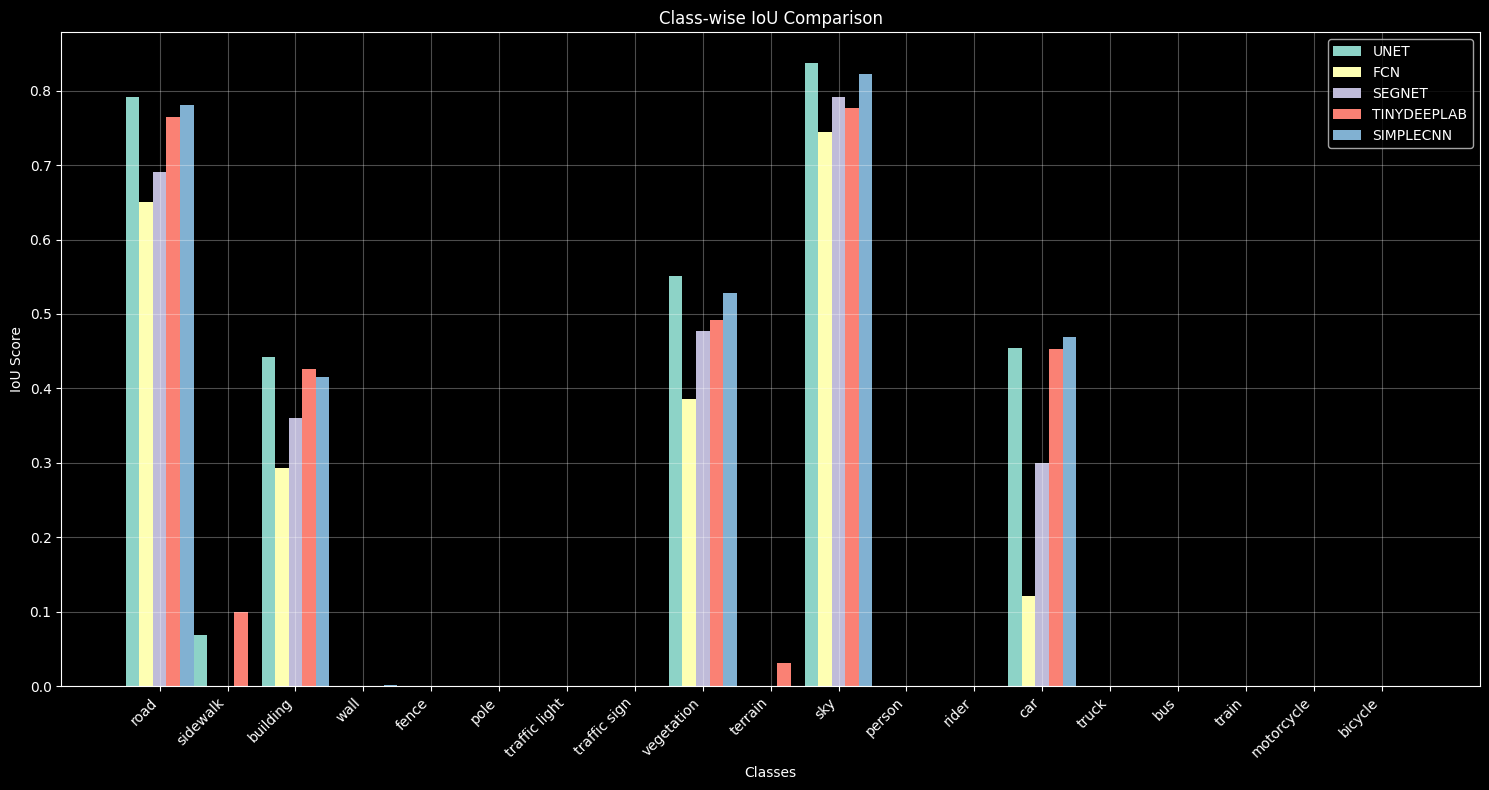

In [ ]:
valid_models = [m for m in model_names if m in results and results[m]['mean_iou'] > 0]

if valid_models:
    fig, ax = plt.subplots(figsize=(15, 8))

    x = np.arange(len(BDD_CLASSES))
    width = 0.2
    multiplier = 0

    for model_name in valid_models:
        offset = width * multiplier
        class_ious = results[model_name]['class_ious']
        ax.bar(x + offset, class_ious, width, label=model_name.upper())
        multiplier += 1

    ax.set_xlabel('Classes')
    ax.set_ylabel('IoU Score')
    ax.set_title('Class-wise IoU Comparison')
    ax.set_xticks(x + width * (len(valid_models) - 1) / 2)
    ax.set_xticklabels(BDD_CLASSES, rotation=45, ha='right')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No valid models with IoU scores to display.")

**Congestion Analysis**

In [ ]:
class CongestionAnalysis:
    def __init__(self, class_names, class_colors):
        self.class_names = class_names
        self.class_colors = class_colors
        self.vehicle_classes = ['car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle']
        self.vehicle_indices = [self.class_names.index(c) for c in self.vehicle_classes if c in self.class_names]
        self.road_indices = [0, 1]

    def calculate_congestion_metrics(self, mask):
        vehicle_mask = np.isin(mask, self.vehicle_indices)
        vehicle_pixels = vehicle_mask.sum()

        road_mask = np.isin(mask, self.road_indices)
        road_pixels = road_mask.sum()

        density = vehicle_pixels / road_pixels if road_pixels > 0 else 0

        from scipy import ndimage
        labeled, num_vehicles = ndimage.label(vehicle_mask)

        # Calculate congestion score and level
        if density < 0.05:
            score = density * 10
            level = "Low"
        elif density < 0.15:
            score = 1 + (density - 0.05) * 10
            level = "Moderate"
        elif density < 0.30:
            score = 2 + (density - 0.15) * 6.67
            level = "High"
        else:
            score = min(4, 3 + (density - 0.30) * 3.33)
            level = "Severe"

        # Vehicle breakdown by class
        vehicle_counts = {}
        for cls_idx in self.vehicle_indices:
            cls_name = self.class_names[cls_idx]
            vehicle_counts[cls_name] = (mask == cls_idx).sum()

        return {
            'congestion_level': {'level': level, 'score': score, 'density': density},
            'vehicle_count': {'estimated_count': num_vehicles, 'by_class': vehicle_counts},
            'vehicle_pixels': vehicle_pixels,
            'road_pixels': road_pixels
        }

**Congestion Analysis with selected best Model**


CONGESTION ANALYSIS USING BEST MODEL: TINYDEEPLAB


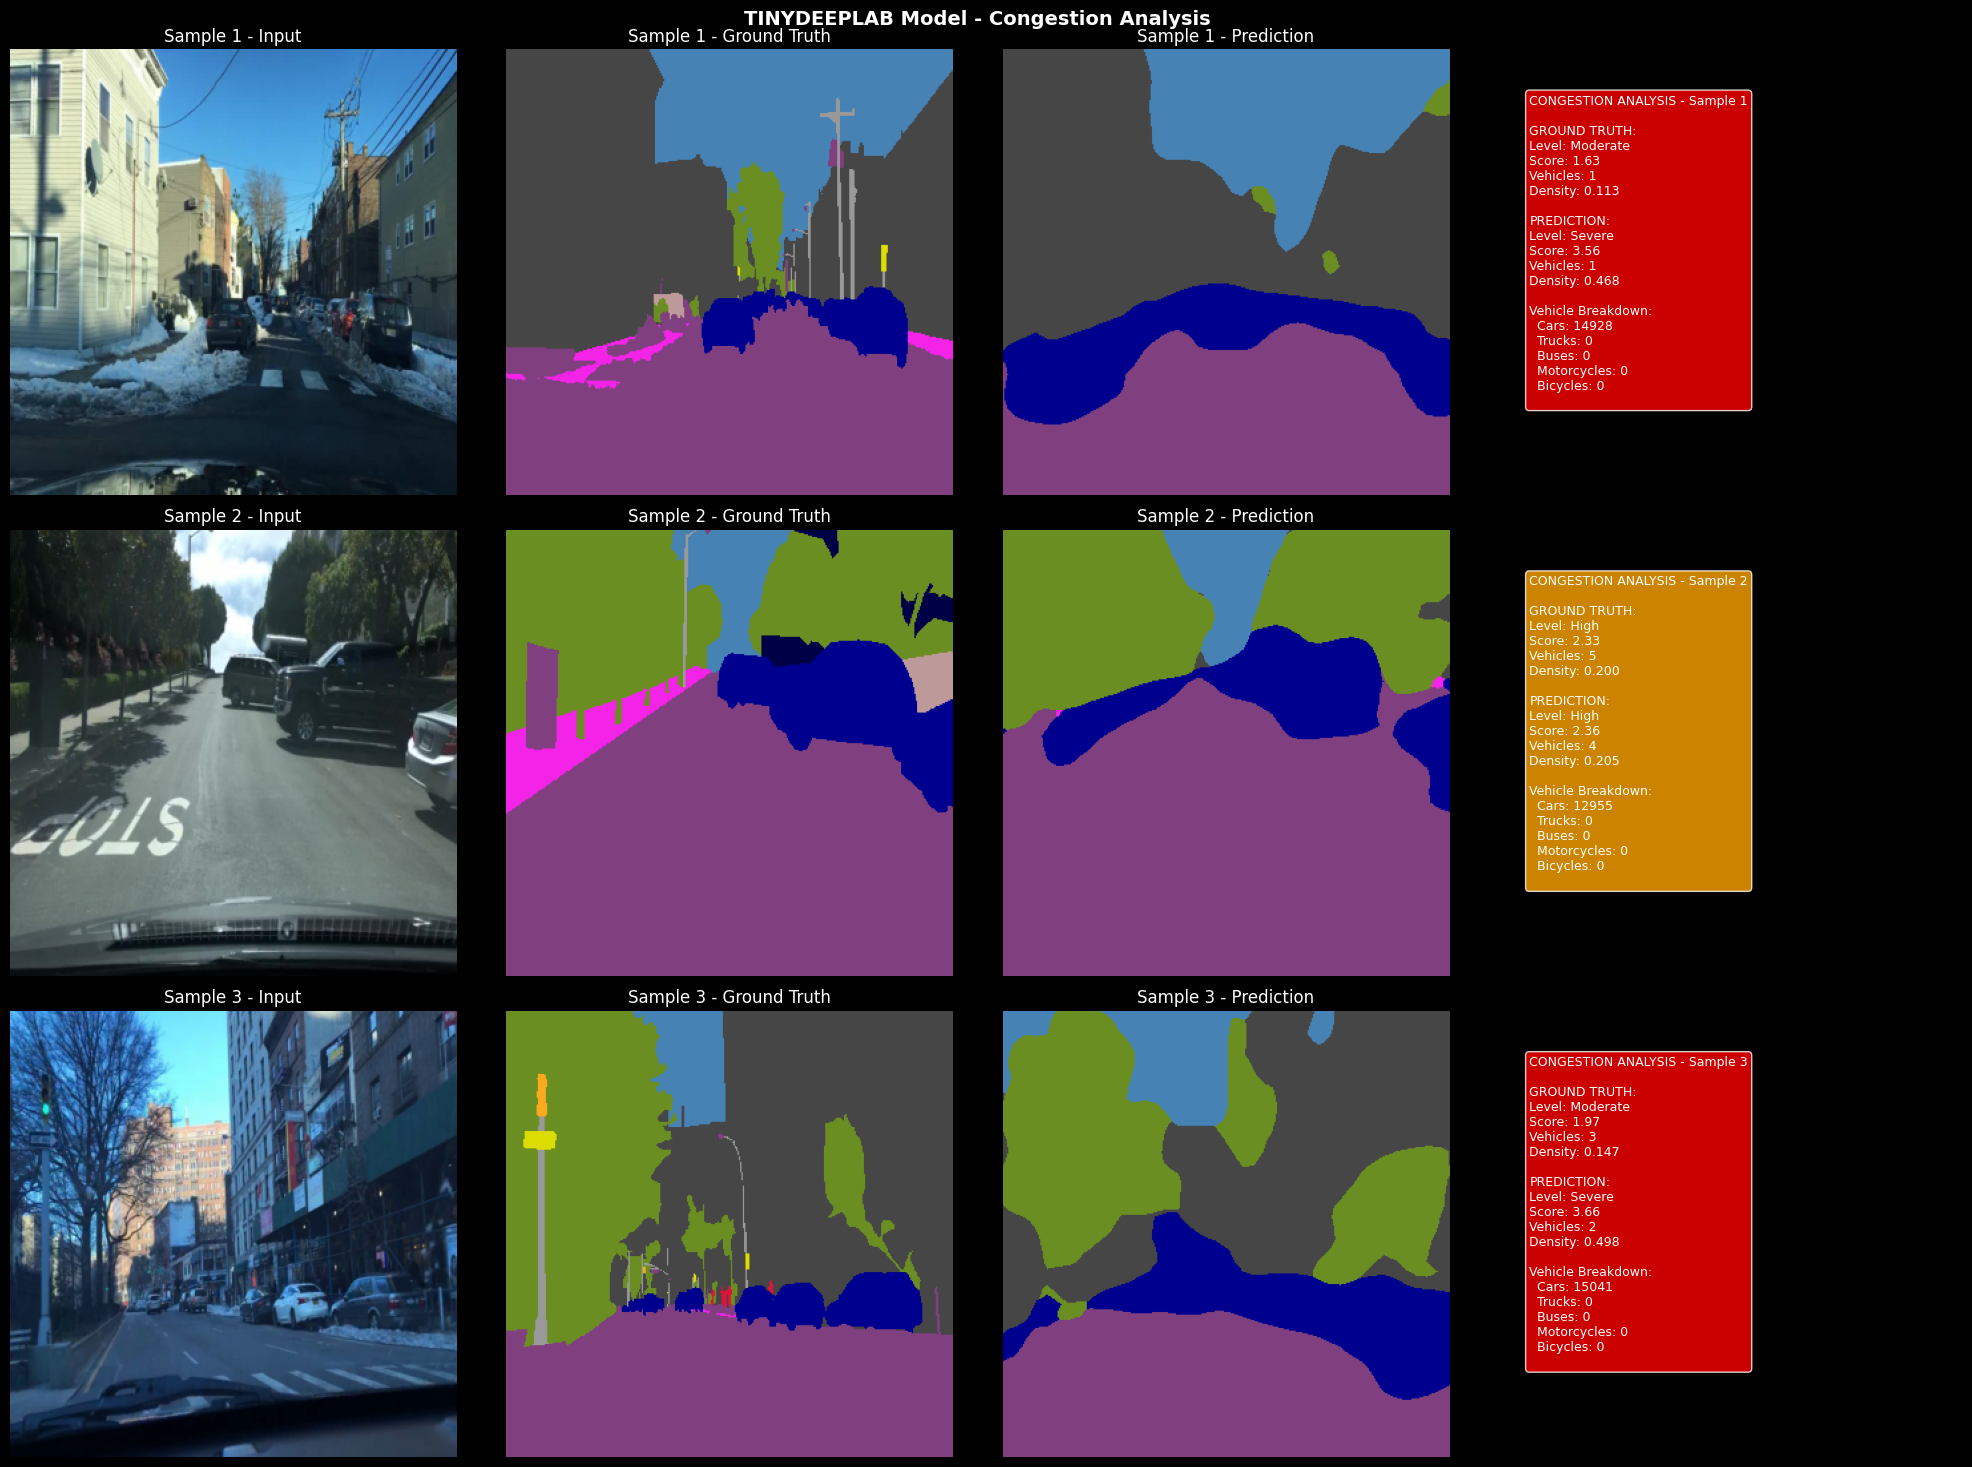

In [ ]:
print("\n" + "="*60)
print(f"CONGESTION ANALYSIS USING BEST MODEL: {best_model_name.upper()}")
print("="*60)

analyzer = CongestionAnalysis(BDD_CLASSES, BDD_COLORS)

# Load best model
best_model.load_state_dict(torch.load(f'best_{best_model_name}_model.pth'))
best_model.eval()

# Visualize predictions with congestion analysis
def visualize_predictions_with_congestion(model, loader, device, dataset, analyzer, num_samples=4):
    images, masks = next(iter(loader))
    images = images[:num_samples].to(device)
    masks = masks[:num_samples]

    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu()

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))

    for i in range(num_samples):
        # Image
        img_display = images[i].cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = img_display * std + mean
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f'Sample {i+1} - Input')
        axes[i, 0].axis('off')

        # Ground Truth
        gt_np = masks[i].numpy()
        gt_rgb = dataset.class_to_rgb(gt_np)
        axes[i, 1].imshow(gt_rgb)
        axes[i, 1].set_title(f'Sample {i+1} - Ground Truth')
        axes[i, 1].axis('off')

        # Prediction
        pred_np = preds[i].numpy()
        pred_rgb = dataset.class_to_rgb(pred_np)
        axes[i, 2].imshow(pred_rgb)
        axes[i, 2].set_title(f'Sample {i+1} - Prediction')
        axes[i, 2].axis('off')

        # Congestion Info
        axes[i, 3].axis('off')

        # Calculate congestion metrics
        gt_metrics = analyzer.calculate_congestion_metrics(gt_np)
        pred_metrics = analyzer.calculate_congestion_metrics(pred_np)

        # Color code based on prediction
        level_colors = {'Low': 'green', 'Moderate': 'yellow', 'High': 'orange', 'Severe': 'red'}
        pred_level = pred_metrics['congestion_level']['level']
        bg_color = level_colors.get(pred_level, 'white')

        info_text = f"""CONGESTION ANALYSIS - Sample {i+1}

GROUND TRUTH:
Level: {gt_metrics['congestion_level']['level']}
Score: {gt_metrics['congestion_level']['score']:.2f}
Vehicles: {gt_metrics['vehicle_count']['estimated_count']}
Density: {gt_metrics['congestion_level']['density']:.3f}

PREDICTION:
Level: {pred_metrics['congestion_level']['level']}
Score: {pred_metrics['congestion_level']['score']:.2f}
Vehicles: {pred_metrics['vehicle_count']['estimated_count']}
Density: {pred_metrics['congestion_level']['density']:.3f}

Vehicle Breakdown:
  Cars: {pred_metrics['vehicle_count']['by_class'].get('car', 0)}
  Trucks: {pred_metrics['vehicle_count']['by_class'].get('truck', 0)}
  Buses: {pred_metrics['vehicle_count']['by_class'].get('bus', 0)}
  Motorcycles: {pred_metrics['vehicle_count']['by_class'].get('motorcycle', 0)}
  Bicycles: {pred_metrics['vehicle_count']['by_class'].get('bicycle', 0)}
"""

        axes[i, 3].text(0.1, 0.9, info_text, transform=axes[i, 3].transAxes,
                       fontsize=9, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor=bg_color, alpha=0.8))

    plt.suptitle(f'{best_model_name.upper()} Model - Congestion Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize predictions with congestion analysis
visualize_predictions_with_congestion(best_model, val_loader, device,
                                     train_loader.dataset, analyzer, num_samples=3)


**Evaluating Accuracy and Confusion Matrix**

Evaluating Congestion:  10%|█         | 1/10 [00:11<01:44, 11.64s/it]


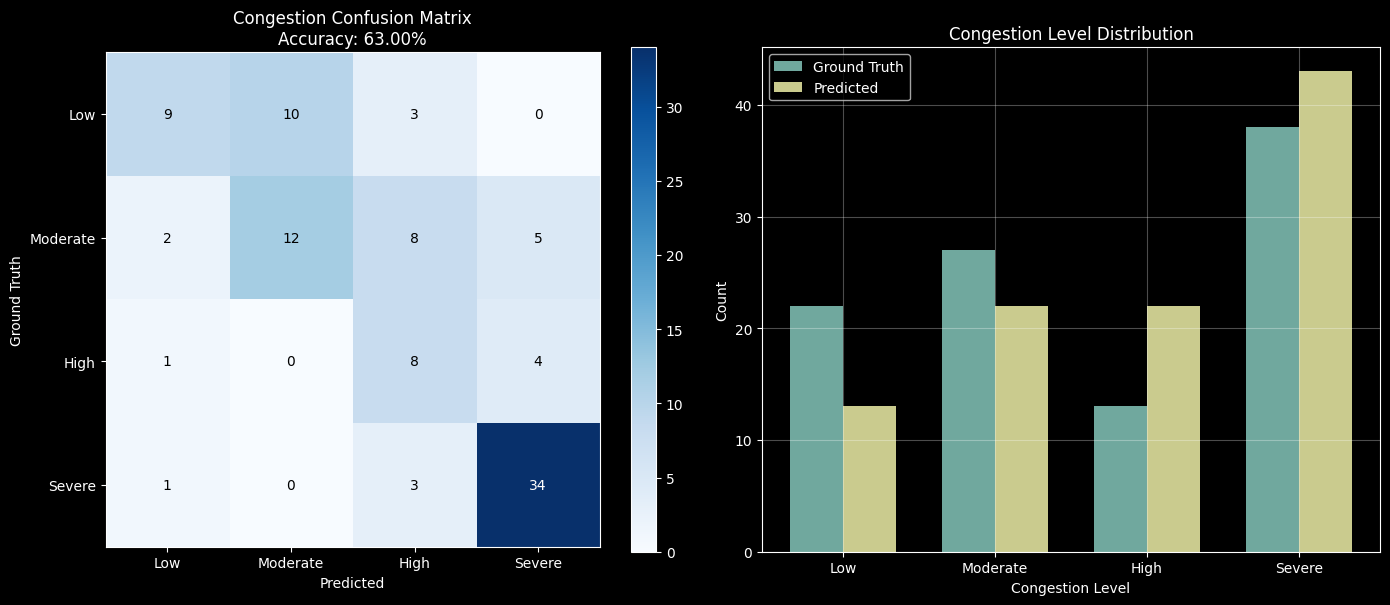


Congestion Prediction Accuracy: 63.00%

Confusion Matrix:
                 Predicted
                 Low       Moderate  High      Severe  
Low          9         10        3         0       
Moderate     2         12        8         5       
High         1         0         8         4       
Severe       1         0         3         34      


In [ ]:
def evaluate_congestion_accuracy(model, loader, device, analyzer, num_samples=100):
    """
    Evaluate how well the model predicts congestion levels
    """
    model.eval()

    congestion_levels = ['Low', 'Moderate', 'High', 'Severe']
    level_to_idx = {level: idx for idx, level in enumerate(congestion_levels)}

    confusion_matrix = np.zeros((4, 4), dtype=int)
    level_counts = {'gt': [0, 0, 0, 0], 'pred': [0, 0, 0, 0]}

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(tqdm(loader, desc='Evaluating Congestion')):
            if batch_idx * len(images) >= num_samples:
                break

            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            for i in range(len(images)):
                gt_np = masks[i].numpy()
                pred_np = preds[i]

                gt_metrics = analyzer.calculate_congestion_metrics(gt_np)
                pred_metrics = analyzer.calculate_congestion_metrics(pred_np)

                gt_level = gt_metrics['congestion_level']['level']
                pred_level = pred_metrics['congestion_level']['level']

                gt_idx = level_to_idx[gt_level]
                pred_idx = level_to_idx[pred_level]

                confusion_matrix[gt_idx, pred_idx] += 1
                level_counts['gt'][gt_idx] += 1
                level_counts['pred'][pred_idx] += 1

    # Calculate accuracy
    correct_predictions = np.trace(confusion_matrix)
    total_predictions = np.sum(confusion_matrix)
    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0

    # Plot confusion matrix
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Confusion Matrix
    im = ax[0].imshow(confusion_matrix, cmap='Blues')
    ax[0].set_xticks(np.arange(4))
    ax[0].set_yticks(np.arange(4))
    ax[0].set_xticklabels(congestion_levels)
    ax[0].set_yticklabels(congestion_levels)
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Ground Truth')
    ax[0].set_title(f'Congestion Confusion Matrix\nAccuracy: {accuracy:.2%}')

    for i in range(4):
        for j in range(4):
            text = ax[0].text(j, i, confusion_matrix[i, j],
                            ha="center", va="center", color="white" if confusion_matrix[i, j] > confusion_matrix.max()/2 else "black")

    plt.colorbar(im, ax=ax[0])

    # Level distribution
    x = np.arange(4)
    width = 0.35
    ax[1].bar(x - width/2, level_counts['gt'], width, label='Ground Truth', alpha=0.8)
    ax[1].bar(x + width/2, level_counts['pred'], width, label='Predicted', alpha=0.8)
    ax[1].set_xlabel('Congestion Level')
    ax[1].set_ylabel('Count')
    ax[1].set_title('Congestion Level Distribution')
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(congestion_levels)
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nCongestion Prediction Accuracy: {accuracy:.2%}")
    print("\nConfusion Matrix:")
    print("                 Predicted")
    print("                 " + "  ".join([f"{l:<8}" for l in congestion_levels]))
    for i, level in enumerate(congestion_levels):
        row = "  ".join([f"{confusion_matrix[i, j]:<8}" for j in range(4)])
        print(f"{level:12} {row}")

    return accuracy, confusion_matrix

# Evaluate congestion accuracy
congestion_accuracy, conf_matrix = evaluate_congestion_accuracy(
    best_model, val_loader, device, analyzer, num_samples=50
)

**Printing Final Summary**

In [ ]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\nBest Performing Model: {best_model_name.upper()}")
print(f"   Mean IoU: {comparison_data[0]['Mean IoU']:.4f}")
print(f"   Best Validation Loss: {comparison_data[0]['Best Val Loss']:.4f}")

print("\nModel Performance Ranking:")
for i, data in enumerate(comparison_data, 1):
    print(f"   {i}. {data['Model']}: IoU={data['Mean IoU']:.4f}, Loss={data['Best Val Loss']:.4f}")

print(f"\nCongestion Detection Accuracy: {congestion_accuracy:.2%}")

print("\nBest model saved as:", f'best_{best_model_name}_model.pth')
print("All model checkpoints saved with prefixes: best_unet_model.pth, best_fcn_model.pth, etc.")


FINAL SUMMARY

Best Performing Model: TINYDEEPLAB
   Mean IoU: 0.1690
   Best Validation Loss: 0.8747

Model Performance Ranking:
   1. TINYDEEPLAB: IoU=0.1690, Loss=0.8747
   2. UNET: IoU=0.1655, Loss=1.0867
   3. SIMPLECNN: IoU=0.1587, Loss=1.4874
   4. SEGNET: IoU=0.1455, Loss=1.3488
   5. FCN: IoU=0.1218, Loss=1.0164

Congestion Detection Accuracy: 63.00%

Best model saved as: best_tinydeeplab_model.pth
All model checkpoints saved with prefixes: best_unet_model.pth, best_fcn_model.pth, etc.


In [ ]:
print("\n" + "="*60)
print("SEGMENTING FIRST 3 TEST IMAGES")
print("="*60)

class TestDataset():
    def __init__(self, image_dir, num_images=3, transform=None, image_size=(512, 512)):
        self.image_dir = image_dir
        self.transform = transform
        self.image_size = image_size

        # Get all image files and take first N
        all_images = sorted([f for f in os.listdir(image_dir)
                            if f.endswith(('.jpg', '.jpeg', '.png'))])
        self.image_files = all_images[:num_images]

        print(f"\nLoading first {len(self.image_files)} test images:")
        for i, img in enumerate(self.image_files, 1):
            print(f"   {i}. {img}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file = self.image_files[idx]

        # Load image
        img_path = os.path.join(self.image_dir, img_file)
        image = Image.open(img_path).convert('RGB')

        # Store original size (width, height)
        original_width, original_height = image.size
        original_image = np.array(image)

        # Resize to consistent size
        image_resized = image.resize(self.image_size, Image.BILINEAR)
        image_np = np.array(image_resized)

        # Apply transforms (normalization)
        image_tensor = torch.from_numpy(image_np.transpose(2, 0, 1)).float() / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_tensor = (image_tensor - mean) / std

        return {
            'image_tensor': image_tensor,
            'image_file': img_file,
            'original_height': original_height,
            'original_width': original_width,
            'original_image': original_image,
            'image_path': img_path
        }

# Create dataset and loader for first 3 images
test_dataset = TestDataset(
    image_dir=Test_Image_Path,
    num_images=3,
    image_size=image_size
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print(f"\nLoaded {len(test_dataset)} test images for segmentation")


SEGMENTING FIRST 3 TEST IMAGES

Loading first 3 test images:
   1. ac517380-00000000.jpg
   2. ac56c836-bdabca21.jpg
   3. ac6d4f42-00000000.jpg

Loaded 3 test images for segmentation


In [ ]:
def segment_test_images(model, test_loader, device, dataset, save_dir='test_predictions'):
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, 'segmentation_masks'), exist_ok=True)
    os.makedirs(os.path.join(save_dir, 'overlays'), exist_ok=True)

    model.eval()
    results = []

    print("\nGenerating segmentations for first 3 test images...")
    print("-" * 60)

    with torch.no_grad():
        for idx, batch in enumerate(test_loader):
            images = batch['image_tensor'].to(device)
            img_file = batch['image_file'][0]

            orig_height = batch['original_height'][0].item() if torch.is_tensor(batch['original_height'][0]) else batch['original_height'][0]
            orig_width = batch['original_width'][0].item() if torch.is_tensor(batch['original_width'][0]) else batch['original_width'][0]
            orig_size = (orig_height, orig_width)

            orig_img = batch['original_image'][0]
            if torch.is_tensor(orig_img):
                orig_img = orig_img.numpy()

            outputs = model(images)
            pred = torch.argmax(outputs, dim=1).cpu().numpy()[0]

            pred_resized = cv2.resize(pred.astype(np.uint8),
                                     (orig_width, orig_height),
                                     interpolation=cv2.INTER_NEAREST)

            # Convert to RGB for visualization
            pred_rgb = dataset.class_to_rgb(pred_resized)


            # Save results
            mask_filename = f'test_{idx+1}_{os.path.splitext(img_file)[0]}_mask.png'

            mask_path = os.path.join(save_dir, 'segmentation_masks', mask_filename)

            cv2.imwrite(mask_path, cv2.cvtColor(pred_rgb, cv2.COLOR_RGB2BGR))

            results.append({
                'index': idx + 1,
                'file': img_file,
                'original_image': orig_img,
                'segmentation': pred_rgb,
                'mask_path': mask_path,
                'class_mask': pred_resized
            })

            print(f"\nTest Image {idx+1}: {img_file}")
            print(f"Original size: {orig_width}x{orig_height}")
            print(f"Segmentation saved: {mask_path}")

    return results

segmentation_results = segment_test_images(
    best_model, test_loader, device,
    train_loader.dataset,  # Using train dataset for class_to_rgb method
    save_dir='test_predictions'
)


Generating segmentations for first 3 test images...
------------------------------------------------------------

Test Image 1: ac517380-00000000.jpg
Original size: 1280x720
Segmentation saved: test_predictions/segmentation_masks/test_1_ac517380-00000000_mask.png

Test Image 2: ac56c836-bdabca21.jpg
Original size: 1280x720
Segmentation saved: test_predictions/segmentation_masks/test_2_ac56c836-bdabca21_mask.png

Test Image 3: ac6d4f42-00000000.jpg
Original size: 1280x720
Segmentation saved: test_predictions/segmentation_masks/test_3_ac6d4f42-00000000_mask.png


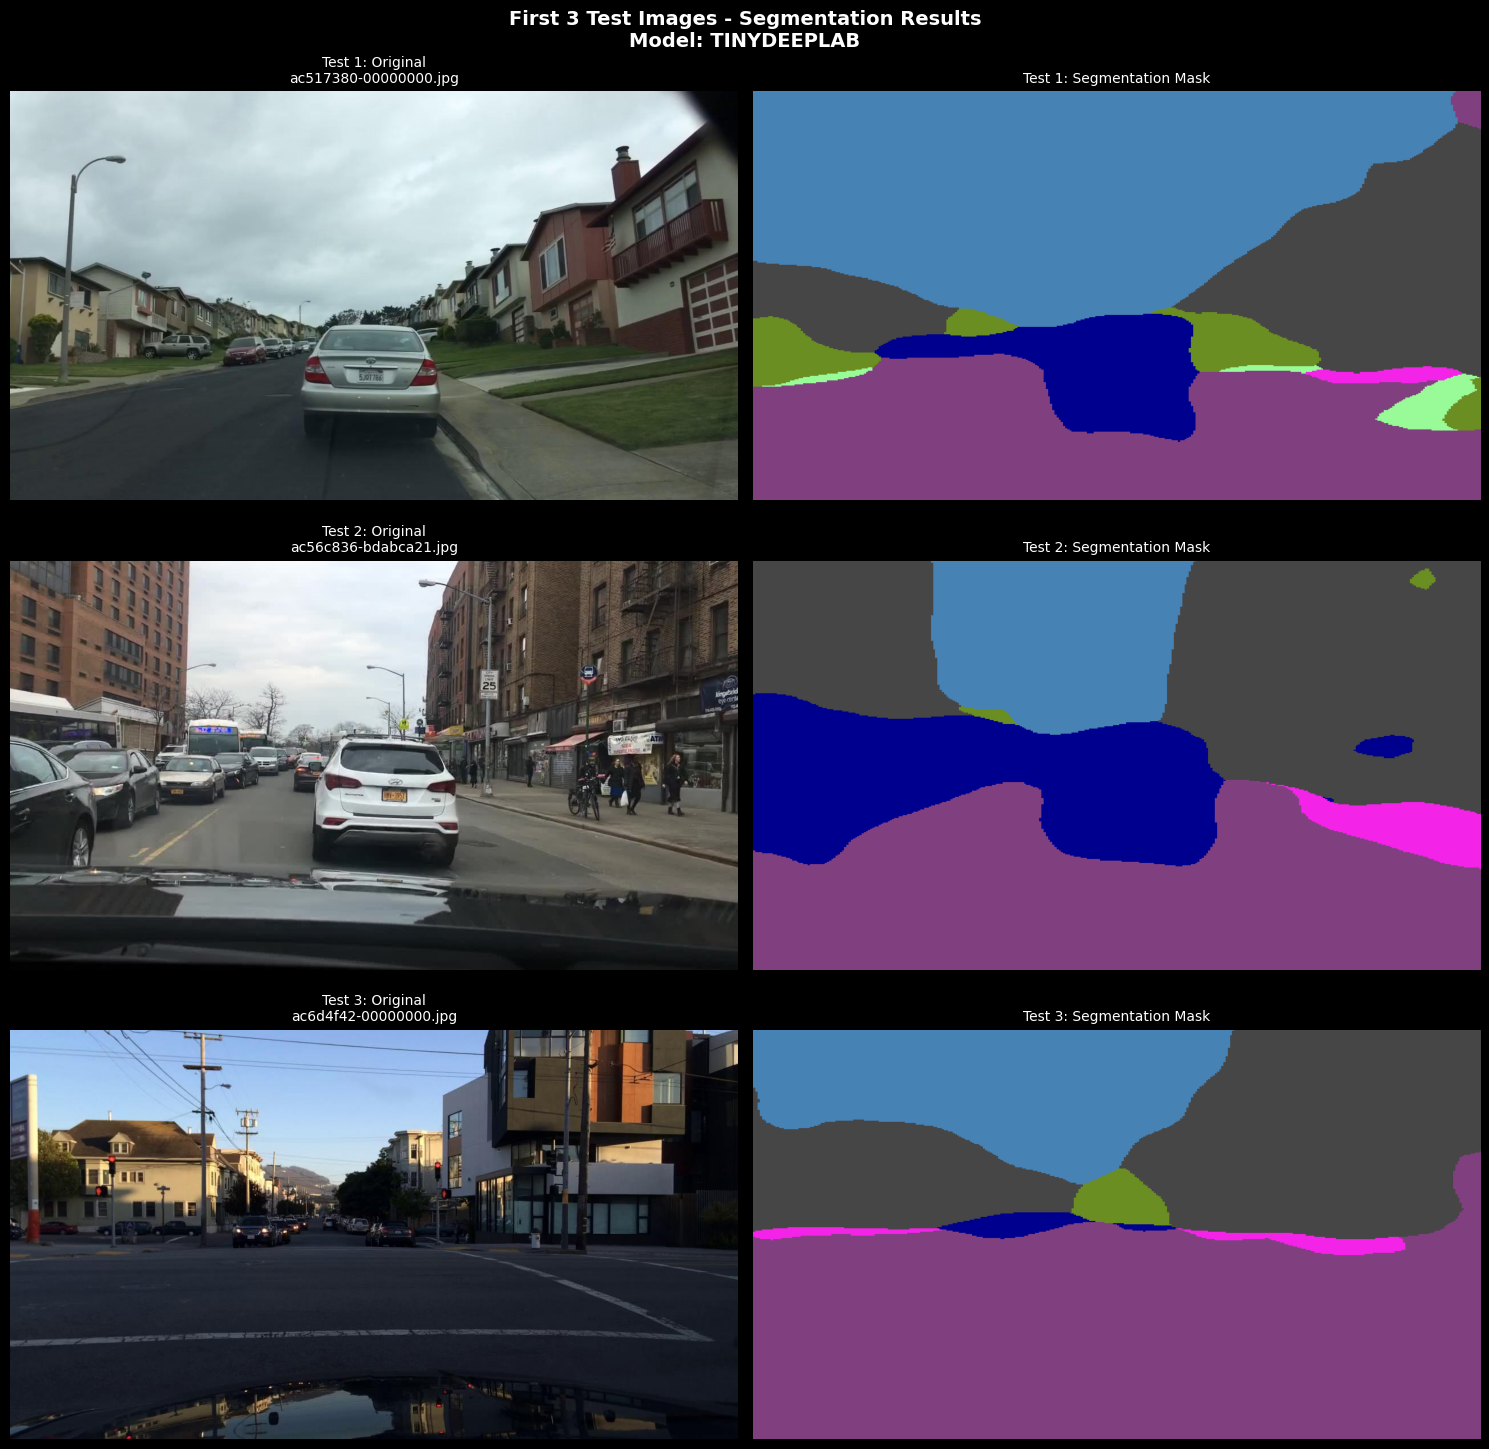


Visualization saved to: test_predictions/segmentation_comparison.png


In [ ]:
def visualize_segmentations(results):
    fig, axes = plt.subplots(3, 2, figsize=(15, 15))

    for i, result in enumerate(results):
        # Original image
        axes[i, 0].imshow(result['original_image'])
        axes[i, 0].set_title(f'Test {result["index"]}: Original\n{result["file"][:30]}', fontsize=10)
        axes[i, 0].axis('off')

        # Segmentation mask
        axes[i, 1].imshow(result['segmentation'])
        axes[i, 1].set_title(f'Test {result["index"]}: Segmentation Mask', fontsize=10)
        axes[i, 1].axis('off')



    plt.suptitle(f'First 3 Test Images - Segmentation Results\nModel: {best_model_name.upper()}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('test_predictions/segmentation_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nVisualization saved to: test_predictions/segmentation_comparison.png")

# Visualize the segmentations
visualize_segmentations(segmentation_results)


CONGESTION ANALYSIS FOR TEST IMAGES


KeyError: 'overlay'

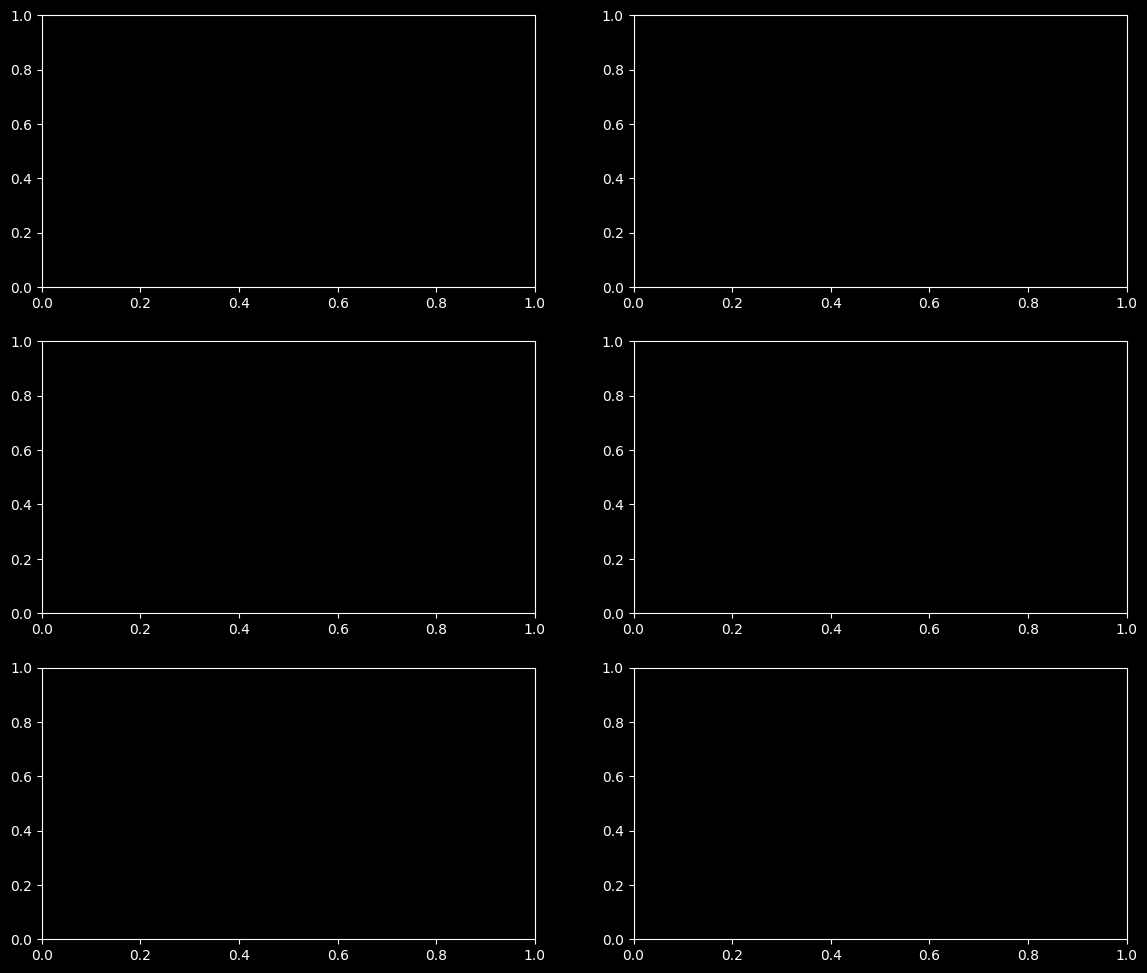

In [ ]:
def analyze_congestion_on_segmented_images(results, analyzer):
    """
    Perform congestion analysis on the segmented test images
    """
    print("\n" + "="*60)
    print("CONGESTION ANALYSIS FOR TEST IMAGES")
    print("="*60)

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    for i, result in enumerate(results):
        # Get class mask (already stored)
        class_mask = result['class_mask']

        # Calculate congestion metrics
        congestion_metrics = analyzer.calculate_congestion_metrics(class_mask)

        # Store results
        result['congestion'] = congestion_metrics

        # Display overlay with congestion info
        axes[i, 0].imshow(result['overlay'])
        axes[i, 0].set_title(f'Test {result["index"]}: {result["file"]}', fontsize=10)
        axes[i, 0].axis('off')

        # Display congestion info
        axes[i, 1].axis('off')

        # Color code based on congestion level
        level_colors = {'Low': '#4CAF50', 'Moderate': '#FFC107',
                       'High': '#FF9800', 'Severe': '#F44336'}
        level = congestion_metrics['congestion_level']['level']
        bg_color = level_colors.get(level, '#9E9E9E')

        info_text = f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   CONGESTION ANALYSIS - Test {result["index"]}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Level: {level}
 Score: {congestion_metrics['congestion_level']['score']:.2f}/4.00
 Density: {congestion_metrics['congestion_level']['density']:.4f}
 Vehicles: {congestion_metrics['vehicle_count']['estimated_count']}

Vehicle Breakdown:
"""
        for vehicle, count in congestion_metrics['vehicle_count']['by_class'].items():
            if count > 0:
                info_text += f"   • {vehicle}: {count:,} pixels\n"

        axes[i, 1].text(0.1, 0.95, info_text, transform=axes[i, 1].transAxes,
                       fontsize=9, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor=bg_color, alpha=0.3),
                       family='monospace')

        print(f"\nTest Image {result['index']}: {result['file']}")
        print(f"Congestion Level: {level}")
        print(f"Congestion Score: {congestion_metrics['congestion_level']['score']:.2f}")
        print(f"Estimated Vehicles: {congestion_metrics['vehicle_count']['estimated_count']}")
        print(f"Vehicle Density: {congestion_metrics['congestion_level']['density']:.4f}")

    plt.suptitle(f'Congestion Analysis on Test Images\nModel: {best_model_name.upper()}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('test_predictions/congestion_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    return results

# Run congestion analysis
segmentation_results = analyze_congestion_on_segmented_images(segmentation_results, analyzer)

In [ ]:
def summary_table(results):
    print("\n" + "="*80)
    print("SUMMARY TABLE: TEST IMAGES")
    print("="*80)

    # Create table
    print(f"\n{'Image':<6} {'Filename':<40} {'Congestion':<12} {'Score':<8} {'Vehicles':<10} {'Density':<10}")
    print("-" * 90)

    for result in results:
        congestion = result['congestion']
        # Truncate filename if too long
        filename = result['file'] if len(result['file']) <= 38 else result['file'][:35] + "..."
        print(f"{result['index']:<6} {filename:<40} "
              f"{congestion['congestion_level']['level']:<12} "
              f"{congestion['congestion_level']['score']:<8.2f} "
              f"{congestion['vehicle_count']['estimated_count']:<10} "
              f"{congestion['congestion_level']['density']:<10.4f}")

    print("-" * 90)

    # Calculate averages
    avg_score = np.mean([r['congestion']['congestion_level']['score'] for r in results])
    avg_vehicles = np.mean([r['congestion']['vehicle_count']['estimated_count'] for r in results])
    avg_density = np.mean([r['congestion']['congestion_level']['density'] for r in results])

    print(f"\n{'Average':<6} {'':<40} {'':<12} {avg_score:<8.2f} {avg_vehicles:<10.2f} {avg_density:<10.4f}")

    # Save summary to file
    with open('test_predictions/summary.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("TEST IMAGES - SEGMENTATION SUMMARY\n")
        f.write("="*80 + "\n\n")

        for result in results:
            congestion = result['congestion']
            f.write(f"Test Image {result['index']}: {result['file']}\n")
            f.write(f"  Congestion Level: {congestion['congestion_level']['level']}\n")
            f.write(f"  Congestion Score: {congestion['congestion_level']['score']:.2f}\n")
            f.write(f"  Estimated Vehicles: {congestion['vehicle_count']['estimated_count']}\n")
            f.write(f"  Vehicle Density: {congestion['congestion_level']['density']:.4f}\n")
            f.write(f"  Vehicle Breakdown:\n")
            for vehicle, count in congestion['vehicle_count']['by_class'].items():
                if count > 0:
                    f.write(f"    - {vehicle}: {count:,} pixels\n")
            f.write("\n")

        f.write(f"\nAverages:\n")
        f.write(f"  Avg Congestion Score: {avg_score:.2f}\n")
        f.write(f"  Avg Vehicles: {avg_vehicles:.2f}\n")
        f.write(f"  Avg Density: {avg_density:.4f}\n")

    print(f"\nSummary saved to: test_predictions/summary.txt")

summary_table(segmentation_results)

In [ ]:
print("\n" + "="*60)
print("FIRST 3 TEST IMAGES - SEGMENTATION COMPLETE")
print("="*60)

print(f"\negmentation Results:")
for i, result in enumerate(segmentation_results, 1):
    print(f"\n   Test Image {i}: {result['file']}")
    print(f"      - Segmentation Mask: {result['mask_path']}")
    print(f"      - Overlay Image: {result['overlay_path']}")
    print(f"      - Congestion Level: {result['congestion']['congestion_level']['level']}")
    print(f"      - Congestion Score: {result['congestion']['congestion_level']['score']:.2f}/4.00")
    print(f"      - Vehicles Detected: {result['congestion']['vehicle_count']['estimated_count']}")

print(f"\nAll files saved in:test_predictions/")
print(f"Segmentation masks:test_predictions/segmentation_masks/")
print(f"Overlays: test_predictions/overlays/")
print(f"Summary: test_predictions/summary.txt")
print(f"Visualization: test_predictions/segmentation_comparison.png")
print(f"Congestion analysis: test_predictions/congestion_analysis.png")

print("\n" + "="*60)
print(" Test images have been successfully segmented!")
print("="*60)

# Display one sample result
if segmentation_results:
    print("\n📸 Sample Result Preview:")
    sample = segmentation_results[0]
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(sample['original_image'])
    plt.title(f'Original: {sample["file"][:30]}')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sample['segmentation'])
    plt.title('Segmentation Mask')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(sample['overlay'])
    plt.title(f'Overlay - Congestion: {sample["congestion"]["congestion_level"]["level"]}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()